# Algumas ferramentas Importantes


## Ciclo de vida do Software
- Escopo -> Design -> Buid -> Testing -> Deploy


## Escopo
- A soma dos produtos, serviços e/ou resultados que se espera alcançar ao final do projeto.


## 5W2h
* Oquê?
* Porquê?
* Como?
* Quando?
* Onde?
* Quem?
* Quanto custa?

# A missão do ciêntista de dados:
- Extrair conhecimento de dados desorganizados.


# AGEMC

- Ask
- Get
- Explorer
- Model
- Comunicate (A unica parte que o cliente vê)

# Método Hipotético Dedutivo.
É interessante lembrar que as coisas, na maioria das vezes, não são tão objetivas,
tão bem acertadas, e a abordagem analítica, a que divide para conquistar, nem sempre é a melhor alternativa. Na maioria dos casos é preciso empregarmos uma visão sistemica, aquela que percebe o mundo mais como uma Mass, cheio de várias formas e cores.

## Parte 1.
Geralmente as coisas se iniciam por aqui.
- Observação
- Pergunta
- Pesquisa

## Parte 2.
Quando a primeira parte ocorre do jeito certo chegamos
a esta parte.

- Hipótese
- Extração dos dados
- Análise dos dados
- Análise dos dados


## Parte 3.

- Conclusão.


Pergunta:

Qual o efeito de um período de taxas de juros elevadas nos princípais índices econômicos de um país, geração de postos diretos de trabalho, aprimoramento da capacidade produtiva, geração de empresas.

Obtenção dos dados:

Quais os dados que eu preciso?
- Série histórica das taxas de juros.
- Série histórica de inflação.

In [1]:
# Minha chave de API do FRED (Federal Reserve Data)

API_KEY = "9294d3fde27c9136f028ca04240fbc94"

In [3]:
%%capture
!pip install fredapi

In [ ]:
from fredapi import Fred
import pandas as pd

# Inicialize o cliente com sua chave gratuita
fred = Fred(api_key=API_KEY)

# 1. Taxa Básica de Juros (Federal Funds Effective Rate)
fed_funds = fred.get_series('FEDFUNDS')

# 2. Inflação - CPI Total (Consumer Price Index)
cpi = fred.get_series('CPIAUCSL')

# 3. Inflação - Núcleo do CPI (Core CPI, excluindo alimentos e energia)
core_cpi = fred.get_series('CPILFESL')

# 4. Inflação - PCE (Personal Consumption Expenditures - a métrica oficial do Fed)
pce = fred.get_series('PCEPI')

# 5. Outros Indicadores Macroeconômicos Relevantes
unemployment = fred.get_series('UNRATE')       # Taxa de Desemprego
gdp = fred.get_series('GDP')                   # PIB Nominal (Trimestral)
yield_10y = fred.get_series('GS10')             # Juros dos T-Bills de 10 anos

# Consolidando em um único DataFrame
df = pd.DataFrame({
    'Fed_Funds': fed_funds,
    'CPI': cpi,
    'Core_CPI': core_cpi,
    'PCE': pce,
    'Unemployment': unemployment
}).dropna()

print(df.tail())

In [5]:
from fredapi import Fred
import pandas as pd

In [6]:
# Inicialize o cliente com sua chave gratuita
fred = Fred(api_key=API_KEY)

# 1. Taxa Básica de Juros (Federal Funds Effective Rate)
fed_funds = fred.get_series('FEDFUNDS')

In [12]:
df = pd.DataFrame({"taxa_juros": fed_funds}).reset_index()

In [13]:
df['date_time'] = df['index']

In [14]:
df.head()

,index,taxa_juros,date_time
0,1954-07-01,0.80,1954-07-01
1,1954-08-01,1.22,1954-08-01
2,1954-09-01,1.07,1954-09-01
3,1954-10-01,0.85,1954-10-01
4,1954-11-01,0.83,1954-11-01


In [18]:
df.drop(columns= ['index'], inplace= True)

In [20]:
df.head(10)

,taxa_juros,date_time
0,0.80,1954-07-01
1,1.22,1954-08-01
2,1.07,1954-09-01
3,0.85,1954-10-01
4,0.83,1954-11-01
5,1.28,1954-12-01
6,1.39,1955-01-01
7,1.29,1955-02-01
8,1.35,1955-03-01
9,1.43,1955-04-01


In [23]:
df.sample(10)

,taxa_juros,date_time
154,3.94,1967-05-01
814,0.77,2022-05-01
762,1.41,2018-01-01
249,5.49,1975-04-01
325,17.82,1981-08-01
233,9.95,1973-12-01
480,4.26,1994-07-01
722,0.09,2014-09-01
569,1.82,2001-12-01
40,3.28,1957-11-01


In [ ]:
# Qual o período onde a econômia americana enfrentou as maiores taxas de juros?

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 866 entries, 0 to 865
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   taxa_juros  866 non-null    float64       
 1   date_time   866 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(1)
memory usage: 13.7 KB


In [24]:
df.describe()

,taxa_juros,date_time
count,866.00000,866
mean,4.59485,1990-07-17 00:28:16.073902976
min,0.05000,1954-07-01 00:00:00
25%,1.93500,1972-07-08 18:00:00
50%,4.25500,1990-07-16 12:00:00
75%,6.11500,2008-07-24 06:00:00
max,19.10000,2026-08-01 00:00:00
std,3.52771,NaN


In [26]:
df['taxa_juros'].max()

19.1

In [38]:
df[df['taxa_juros'] > 7]

,taxa_juros,date_time
177,7.41,1969-04-01
178,8.67,1969-05-01
179,8.90,1969-06-01
180,8.61,1969-07-01
181,9.19,1969-08-01
...,...,...
433,8.13,1990-08-01
434,8.20,1990-09-01
435,8.11,1990-10-01
436,7.81,1990-11-01


In [39]:
df['year'] = df['date_time'].dt.year

In [40]:
df.tail()

,taxa_juros,date_time,year
861,3.64,2026-04-01,2026
862,3.63,2026-05-01,2026
863,3.63,2026-06-01,2026
864,3.63,2026-07-01,2026
865,3.63,2026-08-01,2026


In [42]:
df.columns

Index(['taxa_juros', 'date_time', 'year'], dtype='object')

In [43]:
df.rename(columns= {'taxa_juros': 'rates'}, inplace= True)

In [45]:
# Agrupando os anos e verificando a maior, menor e a taxa média de cada ano.

df_agrupando_taxas = df.groupby('year').agg({
    'rates': ['min', 'max', 'mean']
}).reset_index()

In [49]:
df_agrupando_taxas['rates']['mean'].max()

16.378333333333334

In [52]:
df_agrupando_taxas[df_agrupando_taxas['rates']['mean'] >= 15]

year  rates                 
            min   max       mean
27  1981  12.37  19.1  16.378333

In [59]:
df_agrupado = df.groupby('year').agg({
    "rates": ['min', 'max', 'mean']
}).reset_index()

In [63]:
ano_1981 = df[df['year'] == 1981].copy()

In [64]:
ano_1981.head()

,rates,date_time,year
318,19.08,1981-01-01,1981
319,15.93,1981-02-01,1981
320,14.70,1981-03-01,1981
321,15.72,1981-04-01,1981
322,18.52,1981-05-01,1981


In [67]:
df.rename(columns= {"date_time": "datetime"}, inplace= True)

In [70]:
ano_1981 = df[df['year'] == 1981].copy()

In [71]:
ano_1981.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12 entries, 318 to 329
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   rates     12 non-null     float64       
 1   datetime  12 non-null     datetime64[ns]
 2   year      12 non-null     int32         
dtypes: datetime64[ns](1), float64(1), int32(1)
memory usage: 336.0 bytes


In [55]:
import matplotlib.pyplot as plt

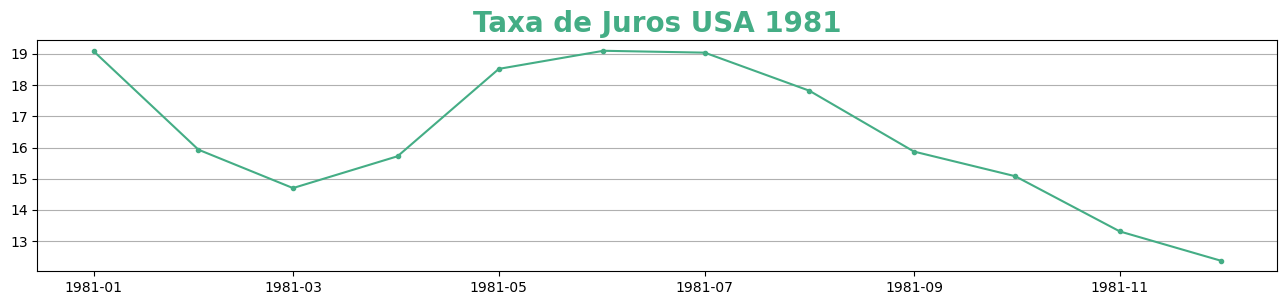

In [90]:
plt.figure(figsize= (16, 3))

plt.plot(ano_1981['datetime'], ano_1981['rates'], marker= '.', color= '#44ad85')

plt.grid(True, linestyle= '-', axis= 'y')

plt.title(
          "Taxa de Juros USA 1981",
          fontfamily= 'sans-serif',
          fontsize= 20,
          fontweight= 'bold',
          color= '#44ad85'
          )


plt.show()